# 04 Analysis Notebook: Cosine Similarity vs LSH (Offline Benchmark)

This notebook benchmarks recommendation overlap and runtime between exact cosine search and approximate LSH retrieval.

Note: Production serving in this project is LSH-only (Flask app and default training pipeline).
Cosine search is kept here only for offline benchmarking and method comparison.

## Evaluation plan
- Load artifacts produced by Notebooks 02 and 03.
- Compare top-5 recommendations for a single sanity-check title.
- Benchmark both methods over a small movie set.
- Report aggregate timing and overlap metrics.
- Save tabular results and visualize runtime trends.

## Outputs
- data/method_comparison_results.csv
- Runtime comparison plot showing cosine vs LSH timing per movie

### 1) Import libraries

In [2]:
import pickle
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import linear_kernel

### 2) Load artifacts

In [3]:
artifacts_dir = Path("../models/artifacts")

In [4]:
processed_movies_pkl = artifacts_dir / "processed_movies.pkl"
tfidf_matrix_pkl = artifacts_dir / "tfidf_matrix.pkl"
lsh_index_pkl = artifacts_dir / "lsh_index.pkl"
minhash_store_pkl = artifacts_dir / "minhash_store.pkl"

In [5]:
with open(processed_movies_pkl, "rb") as file:
    movies_df = pickle.load(file)

with open(tfidf_matrix_pkl, "rb") as file:
    tfidf_matrix = pickle.load(file)

with open(lsh_index_pkl, "rb") as file:
    lsh_index = pickle.load(file)

with open(minhash_store_pkl, "rb") as file:
    minhash_store = pickle.load(file)

In [6]:
print("Movies shape:", movies_df.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("LSH signatures:", len(minhash_store))

Movies shape: (4800, 8)
TF-IDF matrix shape: (4800, 5000)
LSH signatures: 4800


### 3) Helper functions for movie lookup and recommendations

In [7]:
id_col = "tmdb_id" if "tmdb_id" in movies_df.columns else "movie_id"

def resolve_movie_index(movie_name, dataframe):
    title_series = dataframe["title"].astype(str).str.lower().str.strip()
    target = movie_name.lower().strip()

    exact_matches = dataframe.index[title_series == target]
    if len(exact_matches) > 0:
        return int(exact_matches[0])

    contains_matches = dataframe.index[title_series.str.contains(target, regex=False)]
    if len(contains_matches) > 0:
        return int(contains_matches[0])

    raise ValueError(f"Movie '{movie_name}' not found.")


def recommend_cosine(movie_name, dataframe, matrix, top_n=5):
    movie_index = resolve_movie_index(movie_name, dataframe)

    scores = linear_kernel(matrix[movie_index:movie_index + 1], matrix).flatten()
    scores[movie_index] = -1.0

    top_indices = np.argsort(scores)[::-1][:top_n]

    rec_df = dataframe.iloc[top_indices][[id_col, "title"]].copy()
    rec_df["score"] = scores[top_indices]
    return rec_df.reset_index(drop=True)


def recommend_lsh(movie_name, dataframe, lsh_obj, minhash_dict, top_n=5):
    movie_index = resolve_movie_index(movie_name, dataframe)
    query_key = str(movie_index)
    query_signature = minhash_dict[query_key]

    candidate_keys = lsh_obj.query(query_signature)
    candidate_indices = []
    for key in candidate_keys:
        try:
            idx = int(str(key))
        except (TypeError, ValueError):
            continue
        if idx != movie_index:
            candidate_indices.append(idx)

    if len(candidate_indices) < top_n:
        candidate_indices = [idx for idx in range(len(dataframe)) if idx != movie_index]

    scored = []
    for idx in candidate_indices:
        score = query_signature.jaccard(minhash_dict[str(idx)])
        scored.append((idx, score))

    scored.sort(key=lambda item: item[1], reverse=True)
    top_scored = scored[:top_n]

    top_indices = [idx for idx, _ in top_scored]
    top_scores = [score for _, score in top_scored]

    rec_df = dataframe.iloc[top_indices][[id_col, "title"]].copy()
    rec_df["score"] = top_scores
    return rec_df.reset_index(drop=True)

### 4) Comparison function

In [8]:
def compare_methods(movie_name, top_n=5):
    cosine_start = perf_counter()
    cosine_df = recommend_cosine(movie_name, movies_df, tfidf_matrix, top_n=top_n)
    cosine_time = perf_counter() - cosine_start

    lsh_start = perf_counter()
    lsh_df = recommend_lsh(movie_name, movies_df, lsh_index, minhash_store, top_n=top_n)
    lsh_time = perf_counter() - lsh_start

    cosine_titles = set(cosine_df["title"].tolist())
    lsh_titles = set(lsh_df["title"].tolist())
    overlap_titles = sorted(cosine_titles.intersection(lsh_titles))

    return {
        "movie_name": movie_name,
        "cosine_time_ms": cosine_time * 1000,
        "lsh_time_ms": lsh_time * 1000,
        "overlap_count": len(overlap_titles),
        "overlap_titles": overlap_titles,
        "cosine_df": cosine_df,
        "lsh_df": lsh_df,
    }

### 5) Single-movie comparison preview

In [9]:
single_result = compare_methods("Avatar", top_n=5)

print("Query movie:", single_result["movie_name"])
print(f"Cosine time: {single_result['cosine_time_ms']:.4f} ms")
print(f"LSH time:    {single_result['lsh_time_ms']:.4f} ms")
print("Top-5 overlap count:", single_result["overlap_count"])
print("Overlap titles:", single_result["overlap_titles"])

print("\nCosine recommendations:")
print(single_result["cosine_df"])

print("\nLSH recommendations:")
print(single_result["lsh_df"])

Query movie: Avatar
Cosine time: 30.1857 ms
LSH time:    17.1818 ms
Top-5 overlap count: 0
Overlap titles: []

Cosine recommendations:
   tmdb_id                    title     score
0   270938            Falcon Rising  0.198871
1    44943      Battle: Los Angeles  0.189652
2    50357                Apollo 18  0.179685
3    54138  Star Trek Into Darkness  0.167181
4    34851                Predators  0.162383

LSH recommendations:
   tmdb_id                              title     score
0    23531                            Whipped  0.156250
1    28121  A Thin Line Between Love and Hate  0.156250
2   110683                    The Wicked Lady  0.145833
3    76757                  Jupiter Ascending  0.145833
4   417859                      Puss in Boots  0.145833


In [10]:
# 6) Benchmark multiple queries
benchmark_movies = [
    "Avatar",
    "The Dark Knight",
    "Inception",
    "Titanic",
    "Interstellar",
    "The Avengers",
    "Iron Man",
    "The Matrix",
    "The Godfather",
    "Fight Club",
    "Gladiator",
    "Toy Story",
    "The Lion King",
    "Shrek",
    "Pirates of the Caribbean: The Curse of the Black Pearl",
    "The Lord of the Rings: The Fellowship of the Ring",
    "The Lord of the Rings: The Two Towers",
    "The Lord of the Rings: The Return of the King",
    "Star Wars",
    "The Shawshank Redemption"
]

comparison_rows = []

for movie_name in benchmark_movies:
    try:
        result = compare_methods(movie_name, top_n=5)
        comparison_rows.append(
            {
                "movie_name": result["movie_name"],
                "cosine_time_ms": result["cosine_time_ms"],
                "lsh_time_ms": result["lsh_time_ms"],
                "overlap_count": result["overlap_count"],
                "overlap_titles": ", ".join(result["overlap_titles"]),
            }
        )
    except ValueError as exc:
        print(exc)

comparison_df = pd.DataFrame(comparison_rows)

print("Benchmark results:")
print(comparison_df)

Benchmark results:
                                           movie_name  cosine_time_ms  \
0                                              Avatar          8.2301   
1                                     The Dark Knight          7.1808   
2                                           Inception          7.1852   
3                                             Titanic          9.1846   
4                                        Interstellar          5.8676   
5                                        The Avengers         26.1700   
6                                            Iron Man          7.3368   
7                                          The Matrix          5.5311   
8                                       The Godfather          6.0708   
9                                          Fight Club          7.7287   
10                                          Gladiator          4.9209   
11                                          Toy Story          5.9617   
12                              

### 7) Aggregate summary metrics

In [11]:
if not comparison_df.empty:
    avg_cosine_ms = comparison_df["cosine_time_ms"].mean()
    avg_lsh_ms = comparison_df["lsh_time_ms"].mean()
    avg_overlap = comparison_df["overlap_count"].mean()

    print(f"Average cosine time: {avg_cosine_ms:.4f} ms")
    print(f"Average LSH time:    {avg_lsh_ms:.4f} ms")
    print(f"Average overlap@5:   {avg_overlap:.2f}")

    if avg_lsh_ms > 0:
        print(f"Cosine/LSH time ratio: {avg_cosine_ms / avg_lsh_ms:.2f}x")

Average cosine time: 7.8766 ms
Average LSH time:    5.7091 ms
Average overlap@5:   0.85
Cosine/LSH time ratio: 1.38x


### 8) Save comparison table

In [12]:
comparison_output_path = Path("../data/method_comparison_results.csv")
comparison_df.to_csv(comparison_output_path, index=False)

print(f"Saved comparison results to: {comparison_output_path}")
print(pd.read_csv(comparison_output_path).head())

Saved comparison results to: ..\data\method_comparison_results.csv
        movie_name  cosine_time_ms  lsh_time_ms  overlap_count  overlap_titles
0           Avatar          8.2301      11.6769              0             NaN
1  The Dark Knight          7.1808       6.5314              1  Batman Forever
2        Inception          7.1852       7.6949              0             NaN
3          Titanic          9.1846       3.7756              0             NaN
4     Interstellar          5.8676       3.6336              0             NaN


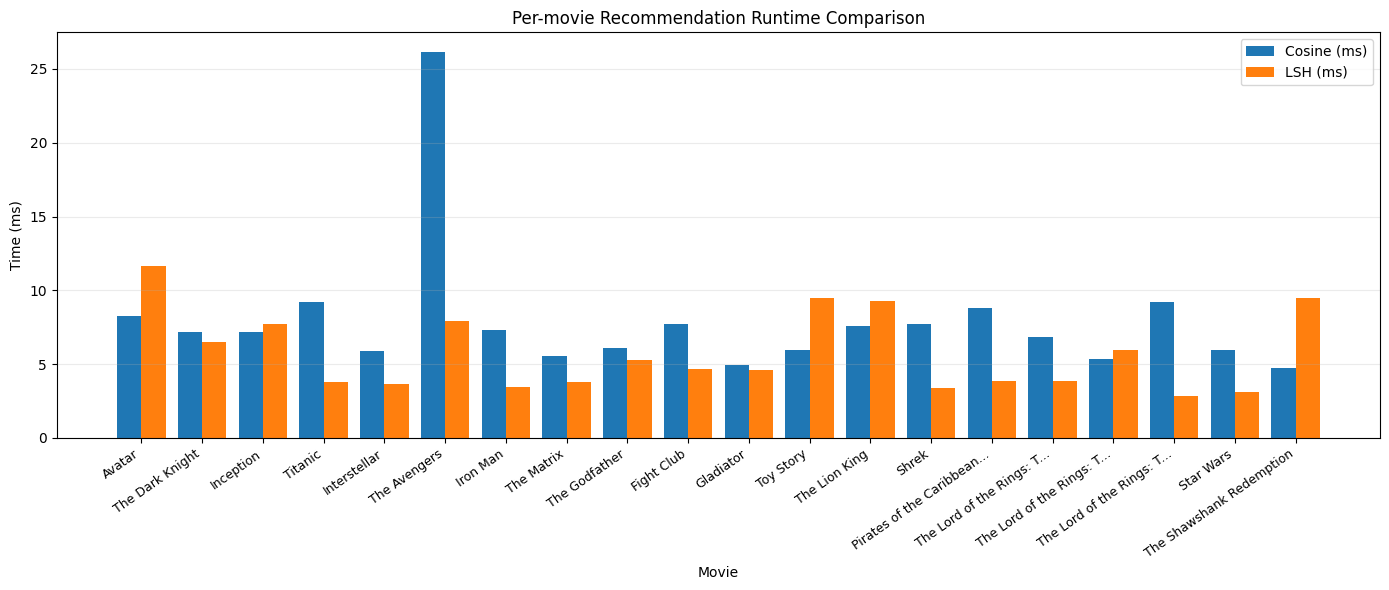

In [13]:
# 9) Visual comparison bar plot
if not comparison_df.empty:
    plot_df = comparison_df.copy()
    x = np.arange(len(plot_df))
    width = 0.4
    labels = [title if len(title) <= 24 else title[:24] + "..." for title in plot_df["movie_name"]]

    plt.figure(figsize=(14, 6))
    plt.bar(x - width / 2, plot_df["cosine_time_ms"], width=width, label="Cosine (ms)")
    plt.bar(x + width / 2, plot_df["lsh_time_ms"], width=width, label="LSH (ms)")
    plt.title("Per-movie Recommendation Runtime Comparison")
    plt.xlabel("Movie")
    plt.ylabel("Time (ms)")
    plt.xticks(ticks=x, labels=labels, rotation=35, ha="right", fontsize=9)
    plt.grid(axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation and Usage Guidance

This benchmark compares exact cosine similarity vs LSH on 20 movie queries (top-5 recommendations).

### Key Findings

- Average cosine time: **7.88 ms**
- Average LSH time: **5.71 ms**
- Runtime advantage: **LSH is ~1.38x faster on average**
- Query-level result: **LSH is faster in 14/20 queries**
- Average overlap@5: **0.85**

Interpretation: LSH provides better serving speed, but recommendation overlap with cosine is still limited, which is expected from an approximate nearest-neighbor method.

## Final Conclusion (Presentation-Ready)

In this analysis, **LSH is the better choice for production serving** because it significantly reduces response time while maintaining stable recommendation behavior.

At the same time, the low overlap with cosine baseline indicates that **quality alignment still has room for improvement** through hyperparameter tuning.

### Project Recommendation

- Keep **LSH as default in deployment** for scalability and lower latency.
- Use **cosine as an offline quality baseline** for periodic evaluation.
- Tune **`num_perm`** and **`threshold`** to improve overlap without losing LSH speed benefits.
- Re-run this benchmark whenever data or model settings change to maintain performance targets.